### Detection of Empty Spaces in Retail Shelf
##### Using Image Processing Techniques 


In [2]:
#imports of Numpy and OpenCV
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
%matplotlib inline

##### Read the Image in CV2

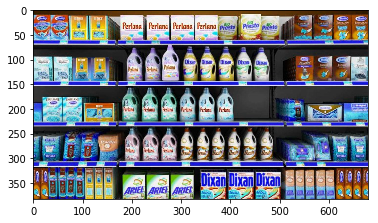

In [3]:
img = cv2.imread(filename='shelf-1.jpg')
plt.imshow(img)

##### Convert RGB image to Single Channel Grayscale Image

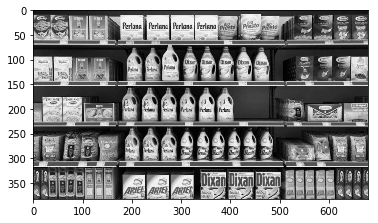

In [4]:
gray = cv2.cvtColor(src=img, code=cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap='gray')

##### Gaussian Filter applied to remove noise and smoothen the image

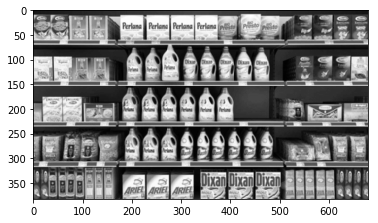

In [5]:
blur_gray = cv2.GaussianBlur(src=gray, ksize=(3, 3), sigmaX=2)
plt.imshow(blur_gray, cmap='gray')

##### Edge Detection using Canny Edge Detector


In [6]:
high_thresh, thresh_im = cv2.threshold(blur_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
lowThresh = 0.5*high_thresh
edges = cv2.Canny(image=blur_gray, threshold1=lowThresh, threshold2=high_thresh, apertureSize=3)

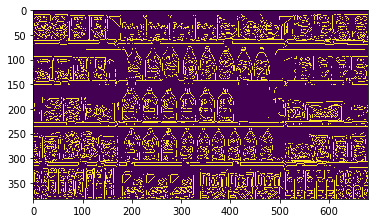

In [7]:
plt.imshow(edges)

##### Hough Lines are calculated.
Different Parameters are set for get optimal lines

In [8]:
rho = 1  # distance resolution in pixels of the Hough grid
theta = np.pi / 180  # angular resolution in radians of the Hough grid
threshold = 15  # minimum number of votes (intersections in Hough grid cell)
min_line_length = 50  # minimum number of pixels making up a line
max_line_gap = 20  # maximum gap in pixels between connectable line segments
line_image = np.copy(img[:,:,0]) * 0  # creating a blank to draw lines on

# Run Hough on edge detected image
# Output "lines" is an array containing endpoints of detected line segments
lines = cv2.HoughLinesP(edges, rho, theta, threshold, np.array([]),
                    min_line_length, max_line_gap)

for line in lines:
    for x1,y1,x2,y2 in line:
        cv2.line(line_image,(x1,y1),(x2,y2),(255,0,0),5)

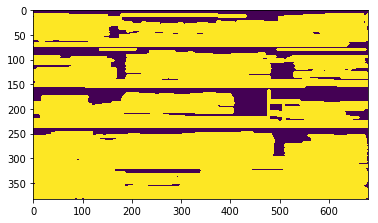

In [9]:
plt.imshow(line_image)

##### Image is binarized
Empty spaces are activated

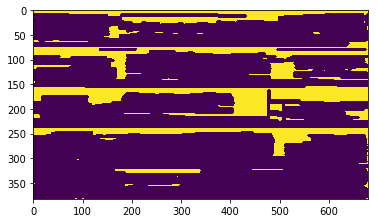

In [10]:
ret, bin_ = cv2.threshold(line_image,0,1,cv2.THRESH_BINARY_INV)
plt.imshow(bin_)

##### Erosion is used to remove false positives/filter mask

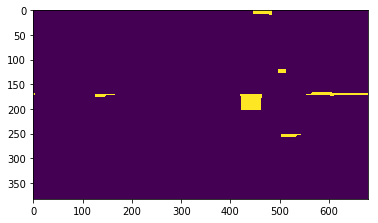

In [22]:
kernel = np.ones((5,5), np.uint8)
bin_dilation = cv2.erode(bin_, kernel, iterations=6) 
plt.imshow(bin_dilation)

#####  Contours are created using the binarized image.
Then bounding rectangles are created!

In [23]:
_, contours, _ = cv2.findContours(bin_dilation, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

In [24]:
boundRect = [None]*len(contours)
contours_poly = [None]*len(contours)
for i, c in enumerate(contours):
    contours_poly[i] = cv2.approxPolyDP(c, 3, True)
    boundRect[i] = cv2.boundingRect(contours_poly[i])

##### Filter some bounding boxes based on size!

In [25]:
min_width = 10
min_height = 10

selected_rectangles = []
for rec in boundRect:
    if rec[2] >= min_width and rec[3] >= min_height:
        if rec[0] > 0 and rec[1] > 0:
            selected_rectangles.append(rec)

##### Showing bounding boxes in RED

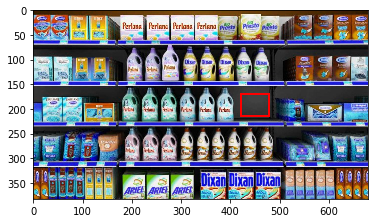

In [26]:
fig,ax = plt.subplots(1)

# Display the image
ax.imshow(img)

# Create a Rectangle patch
for x in selected_rectangles:
    rect = patches.Rectangle((x[0],x[1]),x[2]*1.33, x[3]*1.33,linewidth=2,edgecolor='r',facecolor='none')
    ax.add_patch(rect)

plt.show()

##### Final output in required format!
[id, x,y, x+w, y+h ]

In [27]:
output = []
for i in range(len(selected_rectangles)):
    output.append([i+1, selected_rectangles[i][0], selected_rectangles[i][1], selected_rectangles[i][0]+selected_rectangles[i][2], selected_rectangles[i][1]+selected_rectangles[i][3]])
print(output)

[[1, 421, 170, 464, 203]]


#### End